In [4]:
# =========================
# Import Libraries
# =========================
import pandas as pd
import numpy as np

# =========================
# Load Dataset
# =========================
# Agar CSV file hai to:
df = pd.read_csv("StudentsPerformance.csv")

# First 5 rows check karne ke liye
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
# =========================
# Basic Data Inspection
# =========================

# Shape of dataset
print("Shape of Dataset:", df.shape)

# Column names
print("\nColumns:\n", df.columns)

# Data types
print("\nData Types:\n")
print(df.dtypes)

# Basic info
print("\nDataset Info:\n")
print(df.info())

# Statistical summary
print("\nStatistical Summary:\n")
print(df.describe(include='all'))

Shape of Dataset: (1000, 8)

Columns:
 Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

Data Types:

gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        10

In [7]:
# =========================
# Missing Values Check
# =========================

# Missing values count
print("Missing Values:\n")
print(df.isnull().sum())

# Total missing values
print("\nTotal Missing Values:", df.isnull().sum().sum())

Missing Values:

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Total Missing Values: 0


In [8]:
# =========================
# Duplicate Values Check
# =========================

# Number of duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

# Remove duplicates if needed
df = df.drop_duplicates()

print("Shape After Removing Duplicates:", df.shape)

Duplicate Rows: 0
Shape After Removing Duplicates: (1000, 8)


In [9]:
# =========================
# Create Target Variable
# =========================

# Average score create karna
df['average_score'] = (
    df['math score'] +
    df['reading score'] +
    df['writing score']
) / 3

# Target variable:
# Pass = 1 if average >= 50 else 0

df['target'] = np.where(df['average_score'] >= 50, 1, 0)

# Check target column
df[['average_score', 'target']].head()

,average_score,target
0,72.666667,1
1,82.333333,1
2,92.666667,1
3,49.333333,0
4,76.333333,1


In [10]:
# =========================
# Encoding Categorical Variables
# =========================

# Categorical columns
cat_cols = [
    'gender',
    'race/ethnicity',
    'parental level of education',
    'lunch',
    'test preparation course'
]

# One Hot Encoding
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Encoded dataset preview
df_encoded.head()

,math score,reading score,writing score,average_score,target,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_standard,test preparation course_none
0,72,72,74,72.666667,1,0,1,0,0,0,1,0,0,0,0,1,1
1,69,90,88,82.333333,1,0,0,1,0,0,0,0,0,1,0,1,0
2,90,95,93,92.666667,1,0,1,0,0,0,0,0,1,0,0,1,1
3,47,57,44,49.333333,0,1,0,0,0,0,0,0,0,0,0,0,1
4,76,78,75,76.333333,1,1,0,1,0,0,0,0,0,1,0,1,1


In [11]:
# =========================
# Final Dataset Info
# =========================

print("Final Shape:", df_encoded.shape)

print("\nFinal Columns:\n")
print(df_encoded.columns)

Final Shape: (1000, 17)

Final Columns:

Index(['math score', 'reading score', 'writing score', 'average_score',
       'target', 'gender_male', 'race/ethnicity_group B',
       'race/ethnicity_group C', 'race/ethnicity_group D',
       'race/ethnicity_group E',
       'parental level of education_bachelor's degree',
       'parental level of education_high school',
       'parental level of education_master's degree',
       'parental level of education_some college',
       'parental level of education_some high school', 'lunch_standard',
       'test preparation course_none'],
      dtype='object')


In [12]:
# =========================
# Save Cleaned Dataset
# =========================

df_encoded.to_csv("cleaned_students_data.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [13]:
# =========================
# Import Visualization Libraries
# =========================

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Graph style
sns.set(style="whitegrid")

In [14]:
# =========================
# Correlation Matrix
# =========================

# Sirf numerical columns
numerical_df = df_encoded.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr_matrix = numerical_df.corr()

# Show correlation values
print(corr_matrix)

               math score  reading score  writing score  average_score
math score       1.000000       0.817580       0.802642       0.918746
reading score    0.817580       1.000000       0.954598       0.970331
writing score    0.802642       0.954598       1.000000       0.965667
average_score    0.918746       0.970331       0.965667       1.000000


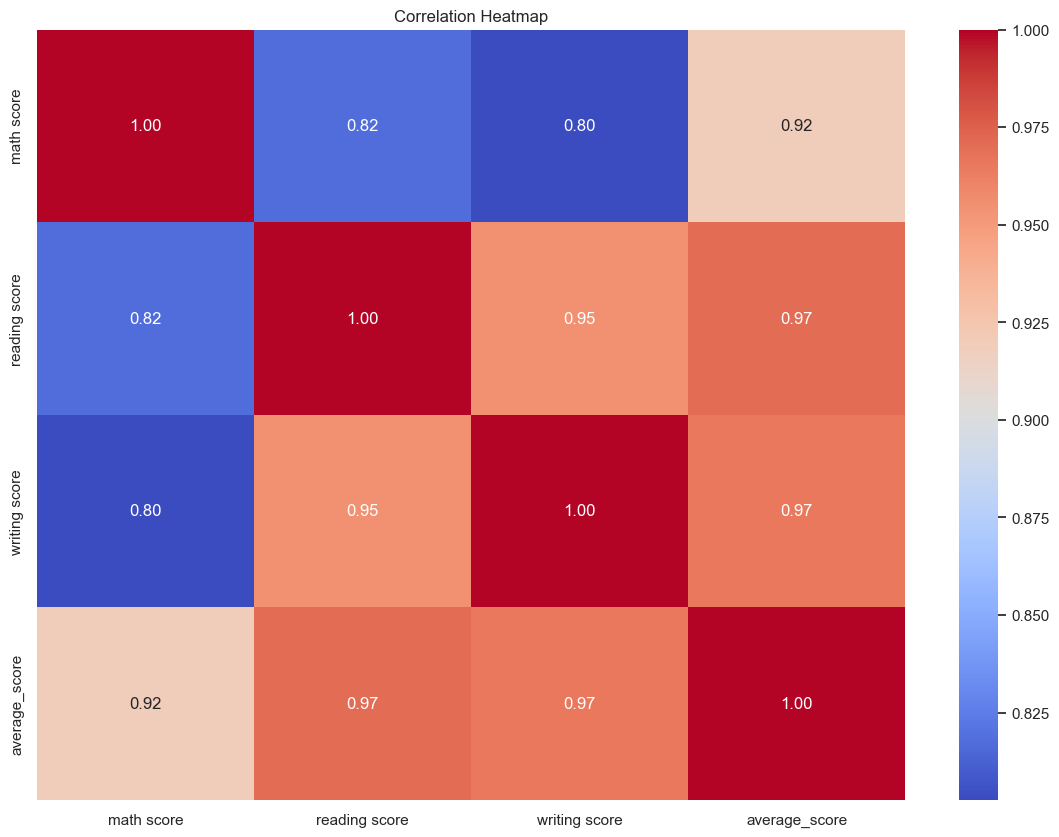

In [15]:
# =========================
# Correlation Heatmap
# =========================

plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [16]:
# =========================
# P-Values Calculation
# =========================

# Empty dataframe for p-values
p_values = pd.DataFrame(
    np.zeros((len(numerical_df.columns), len(numerical_df.columns))),
    columns=numerical_df.columns,
    index=numerical_df.columns
)

# Calculate p-values
for col1 in numerical_df.columns:
    for col2 in numerical_df.columns:
        corr, p = pearsonr(numerical_df[col1], numerical_df[col2])
        p_values.loc[col1, col2] = p

# Display p-values
print("P-Values Matrix:\n")
print(p_values)

P-Values Matrix:

                  math score  reading score  writing score  average_score
math score      0.000000e+00  1.787753e-241  3.376027e-226            0.0
reading score  1.787753e-241   0.000000e+00   0.000000e+00            0.0
writing score  3.376027e-226   0.000000e+00   0.000000e+00            0.0
average_score   0.000000e+00   0.000000e+00   0.000000e+00            0.0


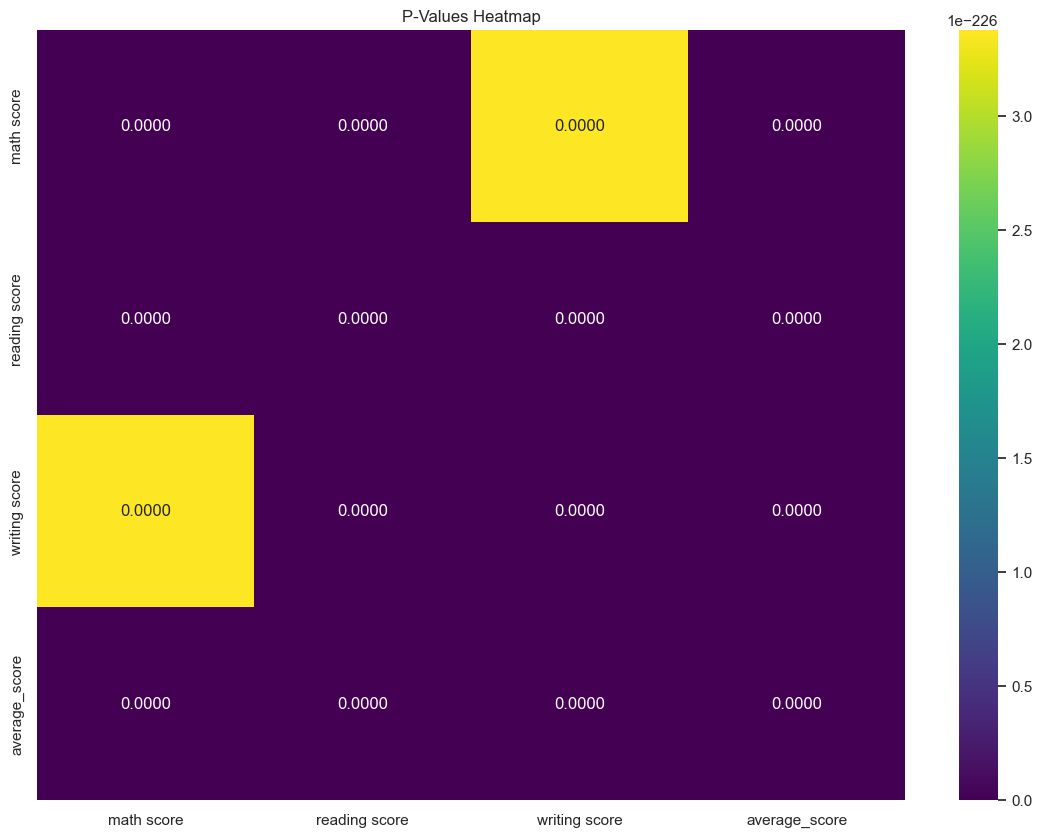

In [17]:
# =========================
# P-Values Heatmap
# =========================

plt.figure(figsize=(14,10))

sns.heatmap(
    p_values,
    annot=True,
    cmap='viridis',
    fmt=".4f"
)

plt.title("P-Values Heatmap")
plt.show()

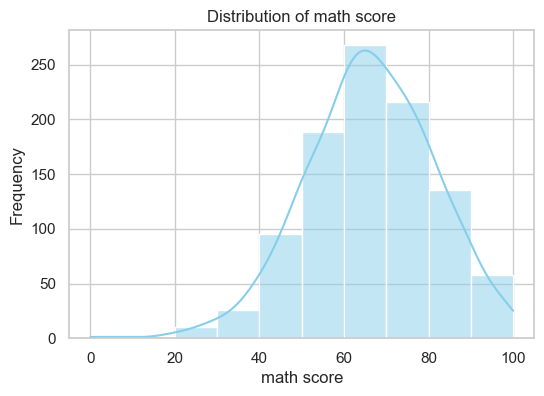

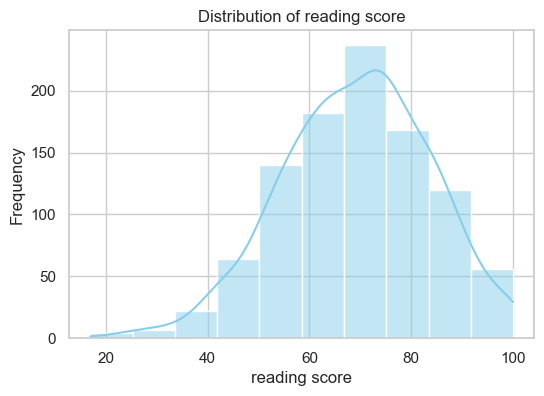

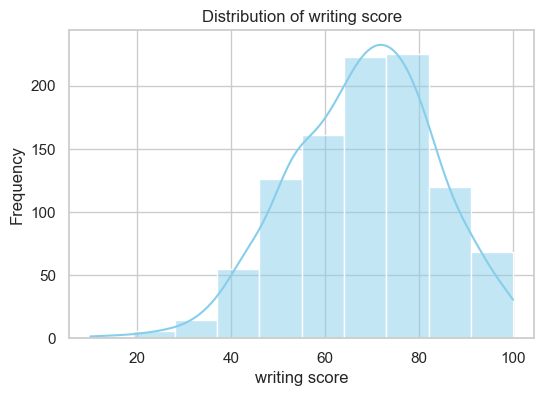

In [18]:
# =========================
# Distribution of Scores
# =========================

score_cols = ['math score', 'reading score', 'writing score']

for col in score_cols:
    plt.figure(figsize=(6,4))
    
    sns.histplot(df[col], kde=True, bins=10, color='skyblue')
    
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    
    plt.show()

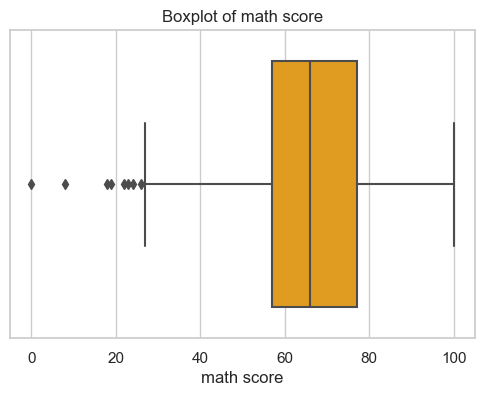

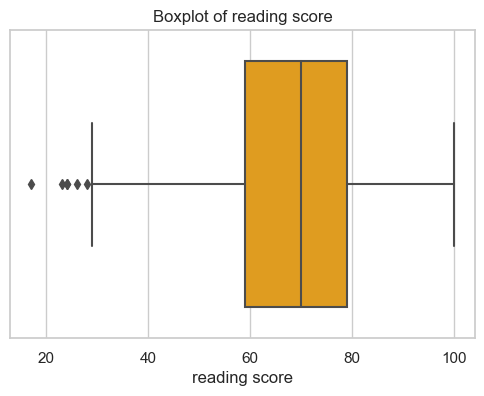

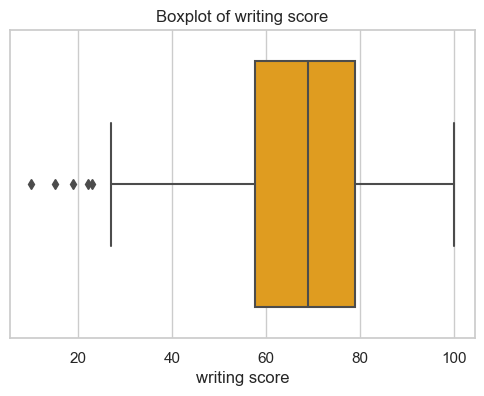

In [19]:
# =========================
# Boxplots for Outlier Detection
# =========================

for col in score_cols:
    plt.figure(figsize=(6,4))
    
    sns.boxplot(x=df[col], color='orange')
    
    plt.title(f"Boxplot of {col}")
    
    plt.show()

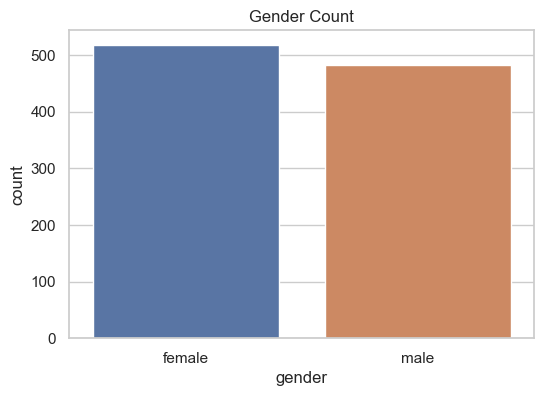

In [20]:
# =========================
# Count Plot for Gender
# =========================

plt.figure(figsize=(6,4))

sns.countplot(x='gender', data=df)

plt.title("Gender Count")
plt.show()

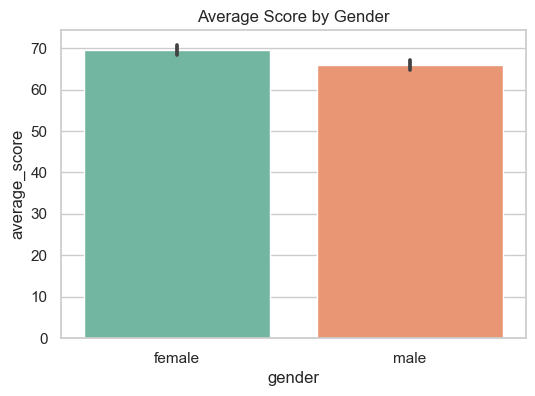

In [21]:
# =========================
# Average Scores by Gender
# =========================

plt.figure(figsize=(6,4))

sns.barplot(
    x='gender',
    y='average_score',
    data=df,
    palette='Set2'
)

plt.title("Average Score by Gender")
plt.show()